In [1]:
from diffusers import StableDiffusionPipeline, DDIMScheduler
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
import numpy as np
from torch.utils.data import  Dataset, DataLoader
from torchvision.transforms.functional import to_pil_image, to_tensor
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from tqdm import tqdm
import os

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
# custom dataset 
class CropOrStitch:  
    def __init__(self, target_size, train = False):

        self.target_size = target_size
        self.train = train

    def __call__(self, image):

        if isinstance(image, torch.Tensor):
            image = to_pil_image(image)

        width, height = image.size

        if width < self.target_size or height < self.target_size:
            repeat_h = (self.target_size // height) + 1
            repeat_w = (self.target_size // width) + 1

            stitched = torch.cat([torch.cat([to_tensor(image)] * repeat_w, dim=2)] * repeat_h, dim=1)

            image = to_pil_image(stitched[:, :self.target_size, :self.target_size])

        if self.train:
            crop_transform = transforms.RandomCrop(self.target_size)
        else:
            crop_transform = transforms.CenterCrop(self.target_size)

        return crop_transform(image)

# mean = [0.485, 0.456, 0.406]
# std = [0.229, 0.224, 0.225]

# denormalize = transforms.Lambda(lambda x: x * torch.tensor(std)[:, None, None] + torch.tensor(mean)[:, None, None])

train_transform = transforms.Compose([
    # CropOrStitch(224, train = True),
    transforms.Resize((256,256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # transforms.Normalize(mean = mean, std = std)
])

test_transform = transforms.Compose([
    # CropOrStitch(224),
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    # transforms.Normalize(mean = mean, std = std)
])

In [3]:
# train(sdv4)
sdv4_trainset = datasets.ImageFolder('/home/dh/venv/dataset/deepfake/genimage/sdv1.4/train',  transform = train_transform)

# test
adm = datasets.ImageFolder('/home/dh/venv/dataset/deepfake/genimage/adm/val', transform = test_transform)
biggan = datasets.ImageFolder('/home/dh/venv/dataset/deepfake/genimage/biggan/val', transform = test_transform)
glide = datasets.ImageFolder('/home/dh/venv/dataset/deepfake/genimage/glide/val', transform = test_transform)
midjourney = datasets.ImageFolder('/home/dh/venv/dataset/deepfake/genimage/midjourney/val', transform = test_transform)
sdv4 = datasets.ImageFolder('/home/dh/venv/dataset/deepfake/genimage/sdv1.4/val', transform = test_transform)
sdv5 = datasets.ImageFolder('/home/dh/venv/dataset/deepfake/genimage/sdv1.5/val', transform = test_transform)
vqdm = datasets.ImageFolder('/home/dh/venv/dataset/deepfake/genimage/vqdm/val', transform = test_transform)
wukong = datasets.ImageFolder('/home/dh/venv/dataset/deepfake/genimage/wukong/val', transform = test_transform)

trainloader = DataLoader(sdv4_trainset, batch_size = 32, shuffle = True)
admloader = DataLoader(adm, batch_size = 32, shuffle = False)
bigganloader = DataLoader(biggan, batch_size = 32, shuffle = False)
glideloader = DataLoader(glide, batch_size = 32, shuffle = False)
midjourneyloader = DataLoader(midjourney, batch_size = 32, shuffle = False)
sdv4loader = DataLoader(sdv4, batch_size = 32, shuffle = False)
sdv5loader = DataLoader(sdv5, batch_size = 32, shuffle = False)
vqdmloader = DataLoader(vqdm, batch_size = 32, shuffle = False)
wukongloader = DataLoader(wukong, batch_size = 32, shuffle = False)

print(len(sdv4_trainset))
print(len(adm))
print(len(biggan))
print(len(glide))
print(len(midjourney))
print(len(sdv4))
print(len(sdv5))
print(len(vqdm))
print(len(wukong))

323997
12000
12000
12000
12000
12000
16000
12000
12000


In [4]:
# Stable Diffusion을 불러와 DDIM 스케줄러로 바꾸는 과정을 의미
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5").to(device)  
#pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4").to(device)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 114.00 MiB. GPU 0 has a total capacity of 2.94 GiB of which 61.19 MiB is free. Including non-PyTorch memory, this process has 2.83 GiB memory in use. Of the allocated memory 2.72 GiB is allocated by PyTorch, and 51.79 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [6]:
# forward process function 
def mu_tilde(model, xt,x0, timestep):
    "mu_tilde(x_t, x_0) DDPM paper eq. 7"
    prev_timestep = timestep - model.scheduler.config.num_train_timesteps // model.scheduler.num_inference_steps
    alpha_prod_t_prev = model.scheduler.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else model.scheduler.final_alpha_cumprod
    alpha_t = model.scheduler.alphas[timestep]
    beta_t = 1 - alpha_t
    alpha_bar = model.scheduler.alphas_cumprod[timestep]
    return ((alpha_prod_t_prev ** 0.5 * beta_t) / (1-alpha_bar)) * x0 +  ((alpha_t**0.5 *(1-alpha_prod_t_prev)) / (1- alpha_bar))*xt

# forward process 원본 이미지 x_0에서 출발해 점진적으로 노이즈를 추가하는 시뮬레이터 
def sample_xts_from_x0(model, x0, num_inference_steps=50):
    """
    Samples from P(x_1:T|x_0)
    """
    # torch.manual_seed(43256465436)
    alpha_bar = model.scheduler.alphas_cumprod
    sqrt_one_minus_alpha_bar = (1-alpha_bar) ** 0.5
    alphas = model.scheduler.alphas
    betas = 1 - alphas

    # 25.03.17 수정
    _, C, H, W = x0.size()

    timesteps = model.scheduler.timesteps.to(model.device)
    t_to_idx = {int(v):k for k,v in enumerate(timesteps)}
    xts = torch.zeros((num_inference_steps+1, C, H, W)).to(x0.device) # 25.03.17 수정
    xts[0] = x0
    for t in reversed(timesteps):
        idx = num_inference_steps-t_to_idx[int(t)]
        xts[idx] = x0 * (alpha_bar[t] ** 0.5) +  torch.randn_like(x0) * sqrt_one_minus_alpha_bar[t]
    return xts

# 텍스트 프롬프트를 텐서로 인코딩. Text to image 
def encode_text(model, prompts):

    text_input = model.tokenizer(
        prompts,
        padding="max_length",
        max_length=model.tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    with torch.no_grad():
        text_encoding = model.text_encoder(text_input.input_ids.to(model.device))[0]
    return text_encoding

# DDPM의 forward 과정을 수동으로 구현 
def forward_step(model, model_output, timestep, sample):
    next_timestep = min(model.scheduler.config.num_train_timesteps - 2,
                        timestep + model.scheduler.config.num_train_timesteps // model.scheduler.num_inference_steps)

    # 2. compute alphas, betas
    alpha_prod_t = model.scheduler.alphas_cumprod[timestep]
    # alpha_prod_t_next = self.scheduler.alphas_cumprod[next_timestep] if next_ltimestep >= 0 else self.scheduler.final_alpha_cumprod

    beta_prod_t = 1 - alpha_prod_t

    # 3. compute predicted original sample from predicted noise also called
    # "predicted x_0" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
    pred_original_sample = (sample - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)

    # 5. TODO: simple noising implementatiom
    next_sample = model.scheduler.add_noise(pred_original_sample,
                                    model_output,
                                    torch.LongTensor([next_timestep]))
    return next_sample


def get_variance(model, timestep): #, prev_timestep):
    prev_timestep = timestep - model.scheduler.config.num_train_timesteps // model.scheduler.num_inference_steps
    alpha_prod_t = model.scheduler.alphas_cumprod[timestep]
    alpha_prod_t_prev = model.scheduler.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else model.scheduler.final_alpha_cumprod
    beta_prod_t = 1 - alpha_prod_t
    beta_prod_t_prev = 1 - alpha_prod_t_prev
    variance = (beta_prod_t_prev / beta_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)
    return variance

def inversion_forward_process(model, x0,
                            etas = None,
                            prog_bar = False,
                            prompt = "",
                            cfg_scale = 3.5,
                            num_inference_steps=50, eps = None):

    if not prompt=="":
        text_embeddings = encode_text(model, prompt)
    uncond_embedding = encode_text(model, "")
    timesteps = model.scheduler.timesteps.to(model.device)

    # 25.03.17 수정
    _, C, H, W = x0.size()

    if etas is None or (type(etas) in [int, float] and etas == 0):
        eta_is_zero = True
        zs = None
    else:
        eta_is_zero = False
        if type(etas) in [int, float]: etas = [etas]*model.scheduler.num_inference_steps
        xts = sample_xts_from_x0(model, x0, num_inference_steps=num_inference_steps)
        alpha_bar = model.scheduler.alphas_cumprod
        zs = torch.zeros((num_inference_steps, C, H, W)).to(x0.device) # 25.03.17 수정
    t_to_idx = {int(v):k for k,v in enumerate(timesteps)}
    xt = x0
    # op = tqdm(reversed(timesteps)) if prog_bar else reversed(timesteps)
    op = tqdm(timesteps) if prog_bar else timesteps

    for t in op:
        # idx = t_to_idx[int(t)]
        idx = num_inference_steps-t_to_idx[int(t)]-1
        # 1. predict noise residual
        if not eta_is_zero:
            xt = xts[idx+1][None]
            # xt = xts_cycle[idx+1][None]

        with torch.no_grad():
            out = model.unet.forward(xt, timestep =  t, encoder_hidden_states = uncond_embedding)
            if not prompt=="":
                cond_out = model.unet.forward(xt, timestep=t, encoder_hidden_states = text_embeddings)

        if not prompt=="":
            ## classifier free guidance
            noise_pred = out.sample + cfg_scale * (cond_out.sample - out.sample)
        else:
            noise_pred = out.sample
        if eta_is_zero:
            # 2. compute more noisy image and set x_t -> x_t+1
            xt = forward_step(model, noise_pred, t, xt)

        else:
            # xtm1 =  xts[idx+1][None]
            xtm1 =  xts[idx][None]
            # pred of x0
            pred_original_sample = (xt - (1-alpha_bar[t])  ** 0.5 * noise_pred ) / alpha_bar[t] ** 0.5

            # direction to xt
            prev_timestep = t - model.scheduler.config.num_train_timesteps // model.scheduler.num_inference_steps
            alpha_prod_t_prev = model.scheduler.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else model.scheduler.final_alpha_cumprod

            variance = get_variance(model, t)
            pred_sample_direction = (1 - alpha_prod_t_prev - etas[idx] * variance ) ** (0.5) * noise_pred

            mu_xt = alpha_prod_t_prev ** (0.5) * pred_original_sample + pred_sample_direction

            z = (xtm1 - mu_xt ) / ( etas[idx] * variance ** 0.5 )
            zs[idx] = z

            # correction to avoid error accumulation
            #xtm1 = mu_xt + ( etas[idx] * variance ** 0.5 )*z
            #xts[idx] = xtm1

    if not zs is None:
        zs[0] = torch.zeros_like(zs[0])

    return xt, zs, xts


def reverse_step(model, model_output, timestep, sample, eta = 0, variance_noise=None):
    # 1. get previous step value (=t-1)
    prev_timestep = timestep - model.scheduler.config.num_train_timesteps // model.scheduler.num_inference_steps
    # 2. compute alphas, betas
    alpha_prod_t = model.scheduler.alphas_cumprod[timestep]
    alpha_prod_t_prev = model.scheduler.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else model.scheduler.final_alpha_cumprod
    beta_prod_t = 1 - alpha_prod_t
    # 3. compute predicted original sample from predicted noise also called
    # "predicted x_0" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
    pred_original_sample = (sample - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)
    # 5. compute variance: "sigma_t(η)" -> see formula (16)
    # σ_t = sqrt((1 − α_t−1)/(1 − α_t)) * sqrt(1 − α_t/α_t−1)
    # variance = self.scheduler._get_variance(timestep, prev_timestep)
    variance = get_variance(model, timestep) #, prev_timestep)
    std_dev_t = eta * variance ** (0.5)
    # Take care of asymetric reverse process (asyrp)
    model_output_direction = model_output
    # 6. compute "direction pointing to x_t" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
    # pred_sample_direction = (1 - alpha_prod_t_prev - std_dev_t**2) ** (0.5) * model_output_direction
    pred_sample_direction = (1 - alpha_prod_t_prev - eta * variance) ** (0.5) * model_output_direction
    # 7. compute x_t without "random noise" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
    prev_sample = alpha_prod_t_prev ** (0.5) * pred_original_sample + pred_sample_direction

    # 8. Add noice if eta > 0
    if eta > 0:
        if variance_noise is None:
            variance_noise = torch.randn(model_output.shape, device=model.device)
        sigma_z =  eta * variance ** (0.5) * variance_noise
        prev_sample = prev_sample + sigma_z

    return prev_sample

def inversion_reverse_process(model,
                    xT,
                    etas = 0,
                    prompts = "",
                    cfg_scales = None,
                    prog_bar = False,
                    zs = None,
                    controller=None,
                    asyrp = False):

    # 수정(25.03.17)
    batch_size = max(1, len(prompts))

    text_embeddings = encode_text(model, prompts)

    # 수정(25.03.17)
    uncond_embedding = encode_text(model, "") if batch_size == 0 else encode_text(model, [""] * batch_size)

    if etas is None: etas = 0
    if type(etas) in [int, float]: etas = [etas]*model.scheduler.num_inference_steps
    assert len(etas) == model.scheduler.num_inference_steps
    timesteps = model.scheduler.timesteps.to(model.device)

    xt = xT.expand(batch_size, -1, -1, -1)
    op = tqdm(timesteps[-zs.shape[0]:]) if prog_bar else timesteps[-zs.shape[0]:]

    t_to_idx = {int(v):k for k,v in enumerate(timesteps[-zs.shape[0]:])}

    i = 0
    for t in op:

        idx = model.scheduler.num_inference_steps-t_to_idx[int(t)]-(model.scheduler.num_inference_steps-zs.shape[0]+1)
        ## Unconditional embedding

        with torch.no_grad():
            uncond_out = model.unet.forward(xt, timestep =  t,
                                            encoder_hidden_states = uncond_embedding)

            ## Conditional embedding
        if prompts:
            with torch.no_grad():
                cond_out = model.unet.forward(xt, timestep =  t,
                                                encoder_hidden_states = text_embeddings)

        z = zs[idx] if not zs is None else None
        z = z.expand(batch_size, -1, -1, -1)
        if prompts:
            ## classifier free guidance
            cfg_scales_tensor = torch.Tensor(cfg_scales).view(-1,1,1,1).to(model.device)
            noise_pred = uncond_out.sample + cfg_scales_tensor * (cond_out.sample - uncond_out.sample)
        else:
            noise_pred = uncond_out.sample

        # 2. compute less noisy image and set x_t -> x_t-1

        # if i == len(t_to_idx) - 2:
        #     print(i, 'ok')
        #     xt = reverse_step(model, noise_pred, t, xt, eta = etas[idx])

        # else:
        #      xt = reverse_step(model, noise_pred, t, xt, eta = etas[idx], variance_noise = z)

        xt = reverse_step(model, noise_pred, t, xt, eta = etas[idx], variance_noise = z)
        # xt = reverse_step(model, noise_pred, t, xt, eta = etas[idx])

        if controller is not None:
            xt = controller.step_callback(xt)

        i += 1

    return xt, zs

In [7]:
# diffusion에서 주어진 이미지를 노이즈로 변환했다가 다시 복원하는 과정 
@torch.no_grad()
def DDPM_invert_sample(
    pipe,
    image,
    prompt = "",
    num_inference_steps=50,
    steps = 0,
    device=device,
):

    pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

    pipe.scheduler.set_timesteps(num_inference_steps)

    w0 = pipe.vae.encode(image * 2 - 1)
    w0 = 0.18215 * w0.latent_dist.sample()

    wt, zs, wts = inversion_forward_process(pipe, w0, etas=1, prompt = prompt, num_inference_steps=num_inference_steps)

    w0, _ = inversion_reverse_process(pipe, xT=wts[steps], etas=1, prog_bar=True, zs=zs[:steps])

    w0 = 1 / pipe.vae.config.scaling_factor * w0
    images = pipe.vae.decode(w0, return_dict=False)[0]
    images = (images / 2 + 0.5).clamp(0, 1)

    return images

NameError: name 'pipe' is not defined

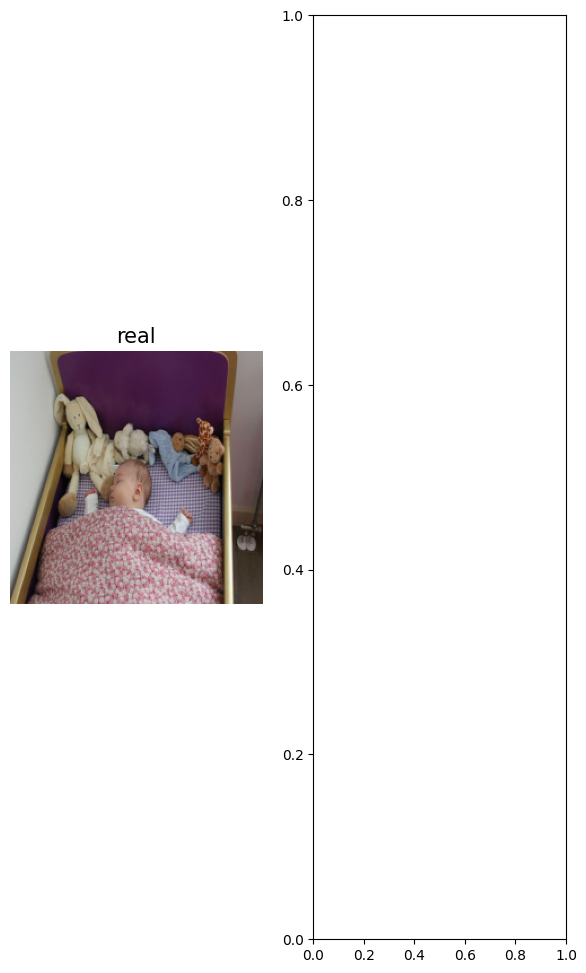

In [8]:
image, y = adm[0]
image = image.unsqueeze(0).to(device)

num_inference_steps = 50

plt.figure(figsize = (15,12))

plt.subplot(1,4,1)
plt.imshow(to_pil_image(image[0].cpu()))
plt.axis('off')
plt.title('real' if y == 0 else 'fake', fontsize = 15)

plt.subplot(1,4,2)
steps = 10
recon_image1 = DDPM_invert_sample(pipe, image, num_inference_steps=num_inference_steps, steps = steps, device = device)[0]
plt.imshow(to_pil_image(recon_image1.cpu()))
plt.axis('off')
plt.title(f'{steps} step', fontsize = 15)

plt.subplot(1,4,3)
steps = 30
recon_image2 = DDPM_invert_sample(pipe, image, num_inference_steps=num_inference_steps, steps = steps, device = device)[0]
plt.imshow(to_pil_image(recon_image2.cpu()))
plt.axis('off')
plt.title(f'{steps} step', fontsize = 15)

plt.subplot(1,4,4)
steps = 50
recon_image3 = DDPM_invert_sample(pipe, image, num_inference_steps=num_inference_steps, steps = steps, device = device)[0]
plt.imshow(to_pil_image(recon_image3.cpu()))
plt.axis('off')
plt.title(f'{steps} step', fontsize = 15)
plt.show()